In [1]:
import os 
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.insert(0, "/home/s2864332/MySYNGAP/ArtifactDetection")
import artifactdetection as ad

### This notebook analyses the power results and marks epochs as noisy or clean based on a slope threshold

Load power file for each animal and separate into clean and noisy epochs based on the spectral slope threshold, append the analytics dataframe which counts the number of clean and noisy epochs for each animal to create an overall analytics dataframe.

**To run the slope analysis, you need to input the following:**
1. Directory path to find power analysis output 
2. Where to save noisy and clean dataframes
3. List of animals (can use the same as script from power analysis script)

In [2]:
directory_path = '/home/s2864332/SYNGAP_Rat_Data/power/'
save_clean_folder = '/home/s2864332/SYNGAP_Rat_Data/clean_folder/'
if not os.path.exists(save_clean_folder):
    os.makedirs(save_clean_folder)
analysis_ls = ['S7063', 'S7064', 'S7068', 'S7069', 'S7070', 'S7071', 'S7072', 'S7074', 
               'S7075', 'S7076', 'S7083', 'S7086', 'S7087', 'S7088', 'S7091', 'S7092', 
               'S7094', 'S7096', 'S7098', 'S7101']
print(len(analysis_ls))

20


In [3]:
analytics_ls = []
analysis = ad.Analysis(directory_path, analysis_ls)
for animal in analysis_ls:
    print(animal)
    clean_power, noise_power, analytics_df = analysis.process_animal(animal = animal, save = True, save_path = save_clean_folder)
    analytics_ls.append(analytics_df)

S7063
S7064
S7068
S7069
S7070
S7071
S7072
S7074
S7075
S7076
S7083
S7086
S7087
S7088
S7091
S7092
S7094
S7096
S7098
S7101


In [4]:
analytics_summary = pd.concat(analytics_ls)
analytics_summary

,Animal_ID,Noisy_Epochs,Clean_Epochs
0,S7063,3709,30851
0,S7064,5234,29326
0,S7068,1912,15368
0,S7069,3392,31168
0,S7070,4210,30350
0,S7071,4524,30036
0,S7072,5743,28817
0,S7074,3248,14032
0,S7075,3055,14225
0,S7076,1674,15606


In [5]:
clean_ls = []
noisy_ls = []
for animal in analysis_ls:
    print(animal)
    clean_df = pd.read_csv(save_clean_folder + f'{animal}_clean_power.csv')
    noise_df = pd.read_csv(save_clean_folder + f'{animal}_noise_power.csv')
    clean_ls.append(clean_df)
    noisy_ls.append(noise_df)

S7063
S7064
S7068
S7069
S7070
S7071
S7072
S7074
S7075
S7076
S7083
S7086
S7087
S7088
S7091
S7092
S7094
S7096
S7098
S7101


In [6]:
clean_concat = pd.concat(clean_ls)
noise_concat = pd.concat(noisy_ls)

/home/s2864332/MySYNGAP/ArtifactDetection/artifactdetection/analyse.py:97: UserWarning: 
The palette list has fewer values (18) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=data_to_plot, x='Frequency', y='Power', hue= hue,


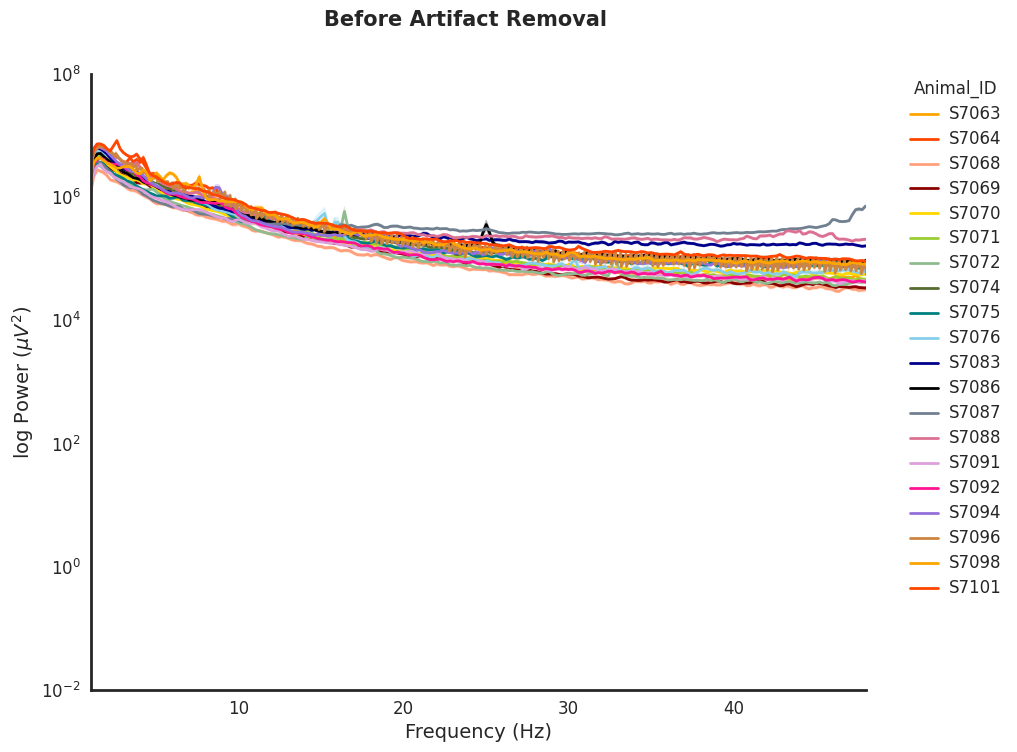

In [8]:
analysis.plot_results(noise_concat, palette=None, hue = 'Animal_ID', ylim = [10**-2, 10**8], title = 'Before Artifact Removal',
            save_folder = '/home/s2864332/SYNGAP_Rat_Data/clean_folder/', save_as = 'before_artifact_removal')

/home/s2864332/MySYNGAP/ArtifactDetection/artifactdetection/analyse.py:97: UserWarning: 
The palette list has fewer values (18) than needed (20) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=data_to_plot, x='Frequency', y='Power', hue= hue,


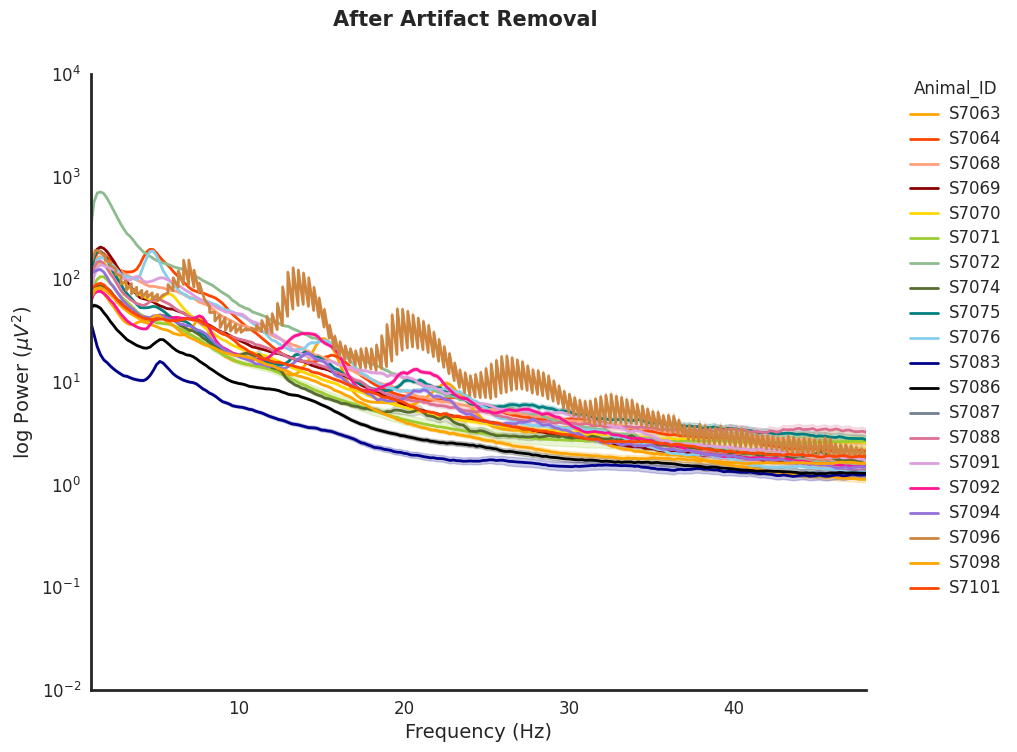

In [ ]:
analysis.plot_results(clean_concat, palette=None, hue = 'Animal_ID', title = 'After Artifact Removal', 
                     save_folder = '/home/s2864332/SYNGAP_Rat_Data/clean_folder/', save_as = 'after_artifact_removal')

#### If you want to plot by genotype or input your own colour palette, you can change these parameters as shown below: 

In [19]:
WT_ls = ['S7068', 'S7070', 'S7071', 'S7074', 'S7086', 'S7091', 'S7098', 'S7101', 'S7083','S7087']
GAP_ls = ['S7063', 'S7064', 'S7069', 'S7072', 'S7075', 'S7076', 'S7088', 'S7092', 'S7094', 'S7096']
wt_blue_palette = ['#001f3f', '#003366', '#0052cc','#0074D9', '#0099ff','#33aaff','#7FDBFF','#39CCCC','#3D9970', 
                   '#2ECC40', '#01FF70', '#B2D8FF', '#6699cc', "#6080A0", "#0E7EEE"]


gap_red_palette = ['#FF4136',  '#FF5733', '#FF6F61', '#FF851B', '#FF8C42','#FF9F80', '#FFDC00', '#85144b', '#B10DC9',
               '#F012BE', '#FF69B4', '#FFC0CB', '#FFB6C1']


In [20]:
wt_df = clean_concat.loc[clean_concat['Animal_ID'].isin(WT_ls)]


In [ ]:

gap_df = clean_concat.loc[clean_concat['Animal_ID'].isin(GAP_ls)]

/home/s2864332/MySYNGAP/ArtifactDetection/artifactdetection/analyse.py:97: UserWarning: 
The palette list has fewer values (8) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=data_to_plot, x='Frequency', y='Power', hue= hue,


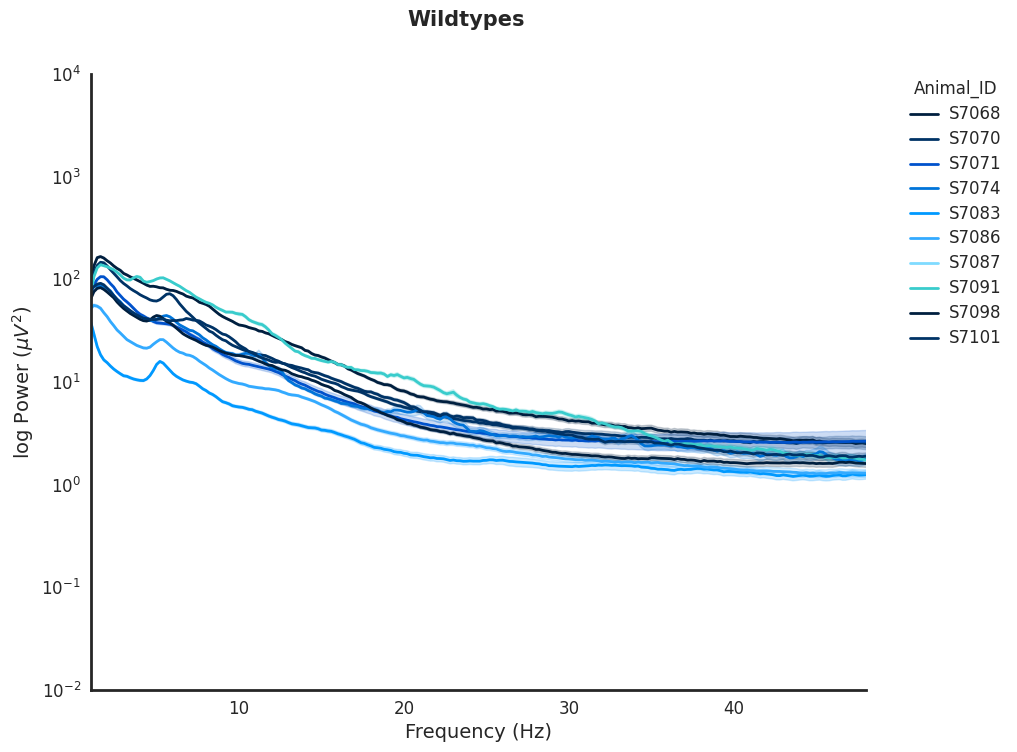

In [21]:
analysis.plot_results(wt_df, palette= wt_blue_palette[0:8], hue = 'Animal_ID', ylim = [10**-2, 10**4], title = 'Wildtypes',
            save_folder = '/home/s2864332/SYNGAP_Rat_Data/clean_folder/', save_as = 'wildtypes')

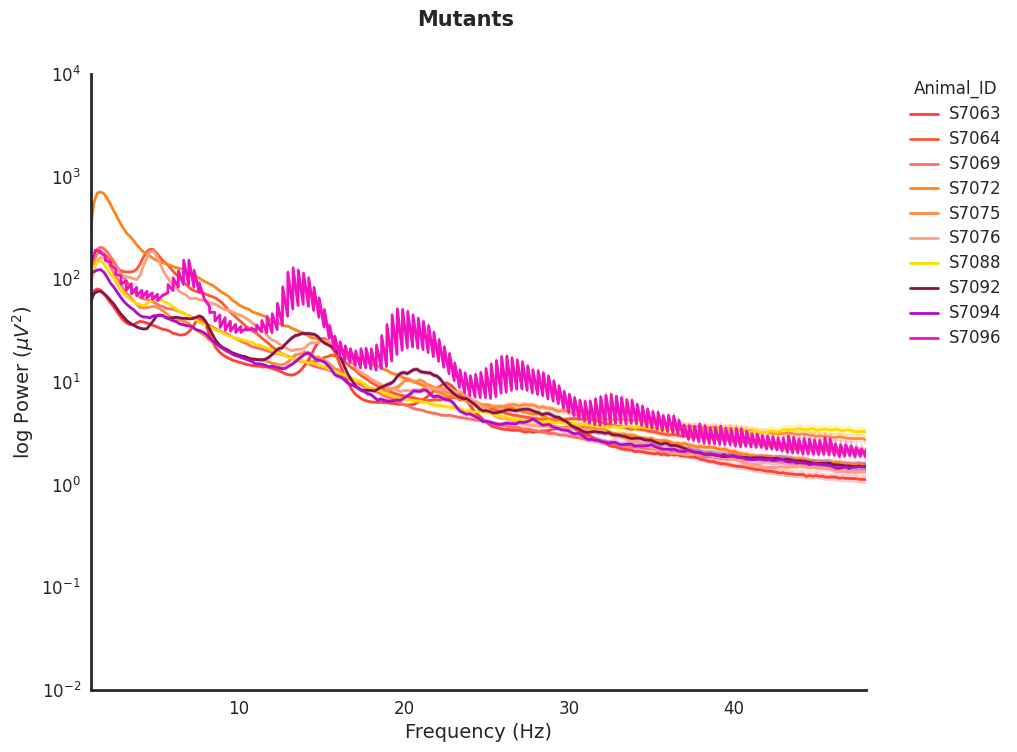

In [18]:
analysis.plot_results(gap_df, palette= gap_red_palette[0:10], hue = 'Animal_ID', ylim = [10**-2, 10**4], title = 'Mutants',
            save_folder = '/home/s2864332/SYNGAP_Rat_Data/clean_folder/', save_as = 'mutants')